## Task 1: Problem Identification

### Problem Type: **Image Classification**

**Why Classification?**
- Each image has a single dominant class/label (normal, scratch, dent, or stain)
- We need to assign one class from a predefined set to each image
- The goal is to predict which category a product surface belongs to
- This is a multi-class (4 classes) supervised learning problem

**Why NOT other problem types?**
- Object Detection (YOLO, R-CNN): Not needed - we don't need to localize defects with bounding boxes
- Semantic Segmentation: Not needed - we don't need pixel-level class labels
- Instance Segmentation: Not needed - we don't need to identify separate instances of defects

In [1]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Metrics and evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Task 2: Dataset Exploration

Let's analyze the image dataset to understand its characteristics.

In [3]:
import os
import pandas as pd

# Unzip the dataset if it hasn't been already
# Assuming the zip file is in /content/ and extracts to /content/part_2_cnn_computer_vision
if not os.path.exists('part_2_cnn_computer_vision'):
    print("Unzipping dataset...")
    !unzip -q /content/part_2_cnn_computer_vision-20260517T050836Z-3-001.zip -d /content/
    print("Dataset unzipped.")

# Set data paths
data_dir = 'part_2_cnn_computer_vision'
image_dir = os.path.join(data_dir, 'images')
labels_file = os.path.join(data_dir, 'labels.csv')

# Load labels
df = pd.read_csv(labels_file)
print("Dataset Overview:")
print(f"Total images: {len(df)}")
print(f"\nClass Distribution:")
print(df['class'].value_counts())
print(f"\nDataset Balance: {df['class'].value_counts().std():.2f} (std dev of class counts)")

Unzipping dataset...
Dataset unzipped.
Dataset Overview:
Total images: 480

Class Distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Dataset Balance: 0.00 (std dev of class counts)


In [4]:
# Analyze image dimensions
sample_images = []
image_dimensions = []
classes = df['class'].unique()

print("\nImage Dimension Analysis:")
print("="*50)

for class_label in classes:
    class_images = df[df['class'] == class_label]['filename'].head(5).tolist()
    for img_file in class_images:
        img_path = os.path.join(data_dir, img_file)
        img = Image.open(img_path)
        image_dimensions.append(img.size)
        sample_images.append((class_label, img_path, img))

# Get common dimensions
width_mode = pd.Series([d[0] for d in image_dimensions]).mode()[0]
height_mode = pd.Series([d[1] for d in image_dimensions]).mode()[0]

print(f"Most common dimensions: {width_mode} x {height_mode}")
print(f"All dimensions consistent: {len(set(image_dimensions)) == 1}")
print(f"Image format: RGB/Grayscale - {sample_images[0][2].mode}")


Image Dimension Analysis:
Most common dimensions: 96 x 96
All dimensions consistent: True
Image format: RGB/Grayscale - RGB


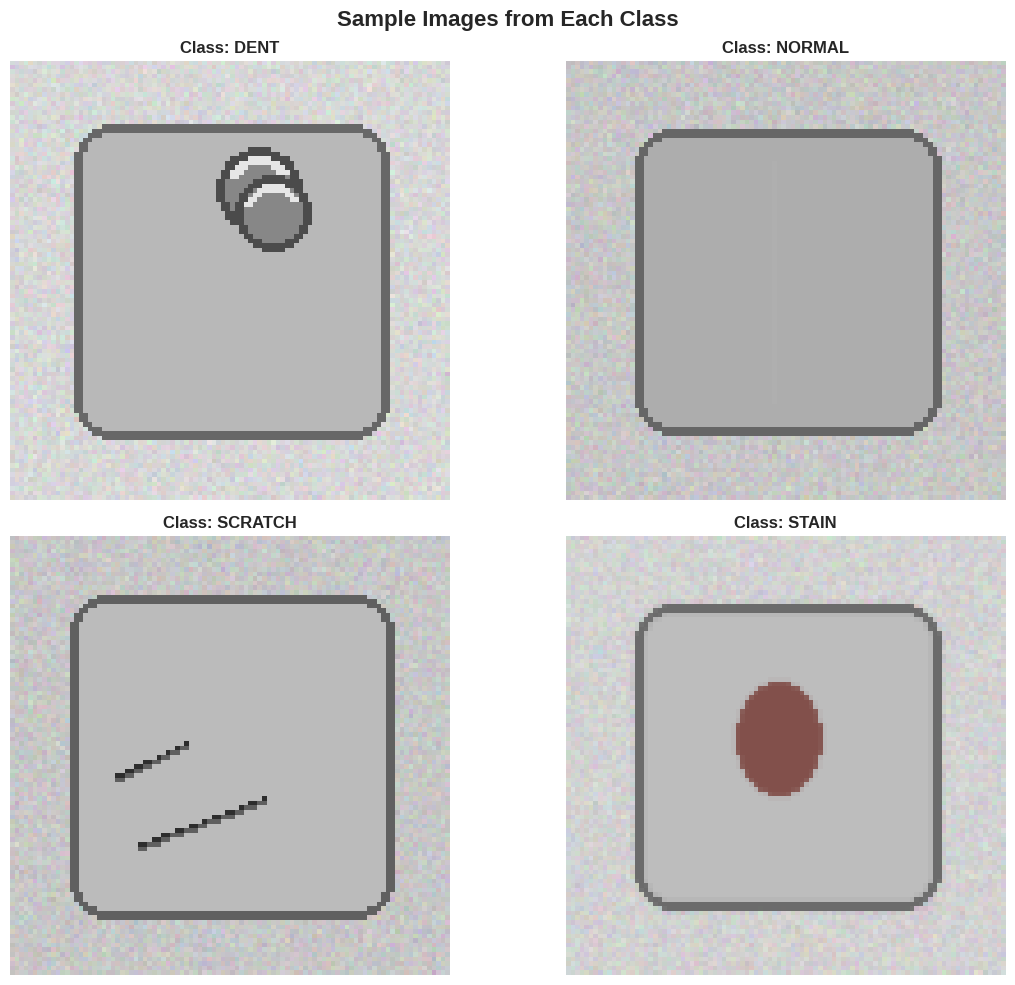

Sample images visualization saved!


In [8]:
import os
# Visualize sample images from each class
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for idx, class_label in enumerate(sorted(df['class'].unique())):
    ax = axes[idx // 2, idx % 2]

    # Get random image from class
    class_images = df[df['class'] == class_label]['filename'].values
    random_image = class_images[np.random.randint(0, len(class_images))]
    img_path = os.path.join(data_dir, random_image)
    img = Image.open(img_path)

    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(f'Class: {class_label.upper()}', fontweight='bold', fontsize=12)
    ax.axis('off')

plt.tight_layout()

# Create the output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Sample images visualization saved!")

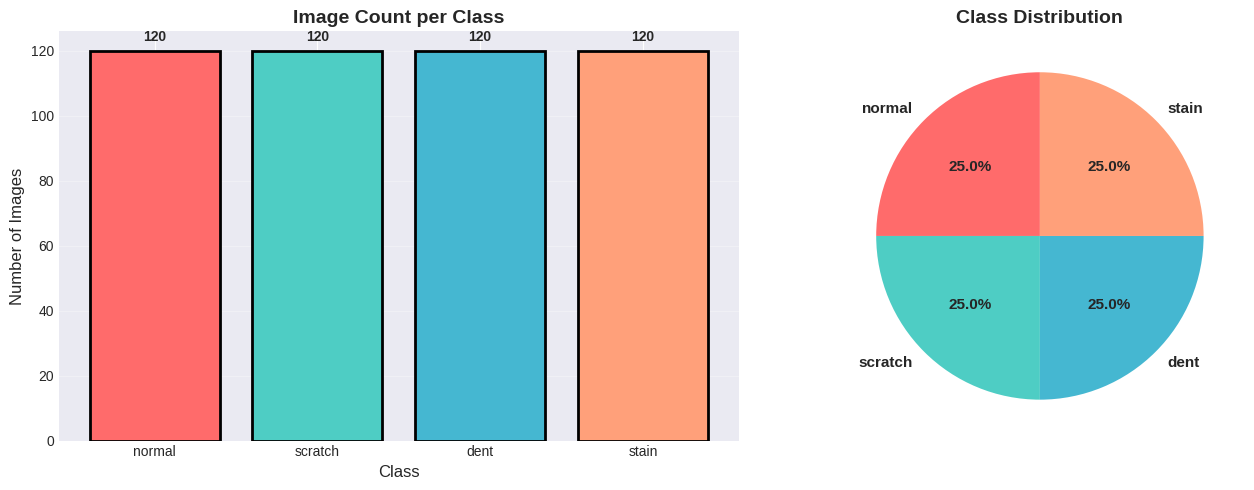

Dataset is perfectly balanced!


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df['class'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=2)
axes[0].set_title('Image Count per Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is perfectly balanced!")

## Task 3: Image Preprocessing

Prepare the data for CNN training.

In [9]:
# Define preprocessing parameters
IMG_SIZE = 224  # Standard size for many architectures
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.2

print(f"Image target size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT}")
print(f"Test split: {TEST_SPLIT}")

Image target size: 224x224
Batch size: 32
Validation split: 0.2
Test split: 0.2


In [10]:
# Load and preprocess all images
def load_and_preprocess_image(image_path, size=(IMG_SIZE, IMG_SIZE)):
    """Load and preprocess a single image"""
    try:
        # Load image
        img = Image.open(image_path)

        # Convert to RGB if grayscale
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Resize
        img = img.resize(size, Image.Resampling.LANCZOS)

        # Convert to numpy array and normalize (0-1 range)
        img_array = np.array(img) / 255.0

        return img_array
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        return None

# Load all images
print("Loading and preprocessing images...")
X = []
y = []
valid_indices = []

for idx, row in df.iterrows():
    img_path = os.path.join(data_dir, row['filename'])
    img = load_and_preprocess_image(img_path)

    if img is not None:
        X.append(img)
        y.append(row['class'])
        valid_indices.append(idx)

    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(df)} images")

X = np.array(X)
y = np.array(y)

print(f"\nDataset loaded successfully!")
print(f"Images shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Images successfully loaded: {len(X)}")

Loading and preprocessing images...
  Processed 100/480 images
  Processed 200/480 images
  Processed 300/480 images
  Processed 400/480 images

Dataset loaded successfully!
Images shape: (480, 224, 224, 3)
Labels shape: (480,)
Images successfully loaded: 480


In [11]:
# Encode class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print(f"\nClass encoding:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {i}")


Class encoding:
  dent: 0
  normal: 1
  scratch: 2
  stain: 3


In [12]:
# Split into train, validation, and test sets
from sklearn.model_selection import train_test_split

# First split: train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

# Second split: validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print(f"\nTraining set class distribution:")
for i, class_name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {class_name}: {count}")

Training set size: 288 (60.0%)
Validation set size: 96 (20.0%)
Test set size: 96 (20.0%)

Training set class distribution:
  dent: 72
  normal: 72
  scratch: 72
  stain: 72


In [13]:
# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# No augmentation for validation/test
val_test_datagen = ImageDataGenerator()

print("Data augmentation configured!")
print("\nAugmentation techniques applied to training data:")
print("  - Rotation: ±20 degrees")
print("  - Width shift: ±10%")
print("  - Height shift: ±10%")
print("  - Horizontal flip: Yes")
print("  - Zoom: ±20%")

Data augmentation configured!

Augmentation techniques applied to training data:
  - Rotation: ±20 degrees
  - Width shift: ±10%
  - Height shift: ±10%
  - Horizontal flip: Yes
  - Zoom: ±20%


## Task 4: CNN Model Creation

Build a custom CNN model with proper architecture.

In [14]:
# Build CNN model
def build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    """
    Build a CNN model for image classification.

    Architecture:
    - Convolutional layers with increasing filters (32 -> 64 -> 128)
    - ReLU activation functions
    - Max pooling layers for dimensionality reduction
    - Batch normalization for training stability
    - Dropout for regularization
    - Flatten layer to convert 2D features to 1D
    - Dense layers for classification
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.BatchNormalization(name='bn1'),
        layers.Dropout(0.25, name='dropout1'),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.BatchNormalization(name='bn2'),
        layers.Dropout(0.25, name='dropout2'),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
        layers.MaxPooling2D((2, 2), name='pool3'),
        layers.BatchNormalization(name='bn3'),
        layers.Dropout(0.25, name='dropout3'),

        # Global average pooling
        layers.GlobalAveragePooling2D(name='global_avg_pool'),

        # Dense layers
        layers.Dense(256, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout4'),
        layers.Dense(128, activation='relu', name='dense2'),
        layers.Dropout(0.5, name='dropout5'),

        # Output layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ])

    return model

# Create model
model = build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=len(class_names))

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 56, 56, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 28, 28, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,340 (1.35 MB)

 Trainable params: 353,892 (1.35 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Compile model
optimizer = Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"\nOptimizer: Adam (learning rate: 1e-3)")
print(f"Loss function: Sparse Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!

Optimizer: Adam (learning rate: 1e-3)
Loss function: Sparse Categorical Crossentropy
Metrics: Accuracy


## Task 5: Model Training and Evaluation

In [24]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model
print("Starting model training...\n")
epochs = 10
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_test_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE),
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting model training...

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 110s 12s/step - accuracy: 0.9340 - loss: 0.1918 - val_accuracy: 0.2500 - val_loss: 4.6066 - learning_rate: 5.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 109s 12s/step - accuracy: 0.9653 - loss: 0.1481 - val_accuracy: 0.2500 - val_loss: 4.8135 - learning_rate: 5.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 109s 12s/step - accuracy: 0.9688 - loss: 0.1108 - val_accuracy: 0.2500 - val_loss: 5.2200 - learning_rate: 5.0000e-04
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 108s 12s/step - accuracy: 0.9653 - loss: 0.1092 - val_accuracy: 0.2500 - val_loss: 5.8517 - learning_rate: 5.0000e-04
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 108s 12s/step - accuracy: 0.9757 - loss: 0.0748 - val_accuracy: 0.2500 - val_loss: 6.7349 - learning_rate: 5.0000e-04
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9885 - loss: 0.0684 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
9/9 ━━━━━━━━━━━━━━━━━━━━ 113s 13s/step - ac

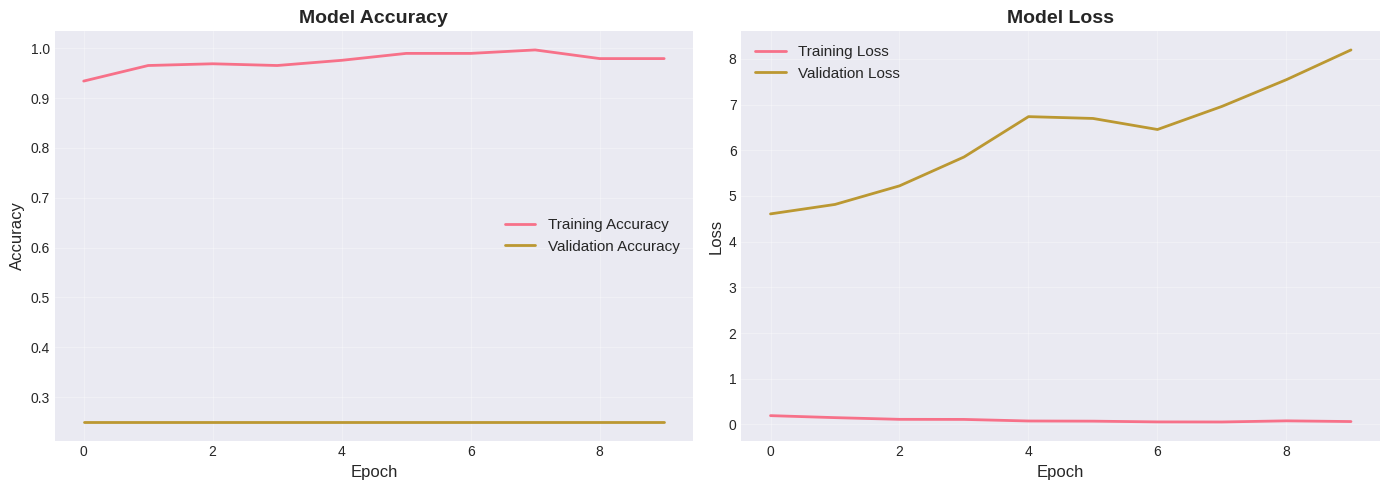

Training curves saved!


In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved!")

In [26]:
# Evaluate on test set
print("Model Evaluation on Test Set")
print("="*50)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f"\nPredictions made for {len(y_test)} test images")

Model Evaluation on Test Set

Test Loss: 4.6059
Test Accuracy: 0.2500 (25.00%)

Predictions made for 96 test images


In [27]:
# Classification report
print("\nDetailed Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=class_names))


Detailed Classification Report:
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.25      1.00      0.40        24
     scratch       0.00      0.00      0.00        24
       stain       0.00      0.00      0.00        24

    accuracy                           0.25        96
   macro avg       0.06      0.25      0.10        96
weighted avg       0.06      0.25      0.10        96



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


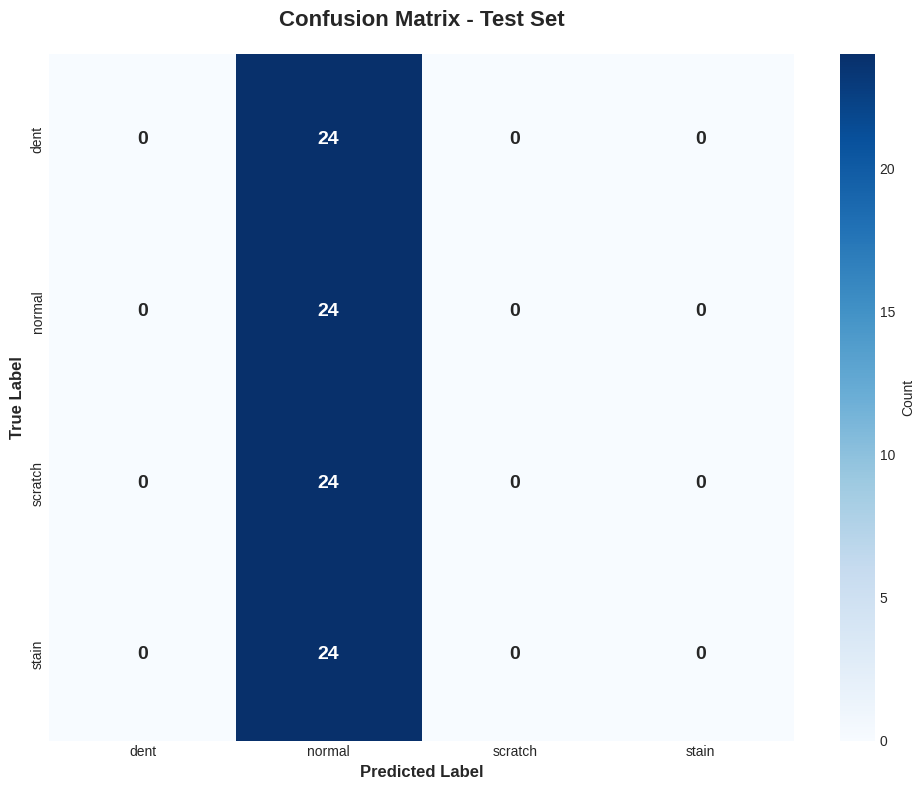

Confusion matrix saved!


In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax)

ax.set_title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved!")

In [29]:
# Per-class accuracy
print("\nPer-Class Accuracy:")
print("="*50)
for i, class_name in enumerate(class_names):
    mask = y_test == i
    class_accuracy = np.mean(y_pred_classes[mask] == y_test[mask])
    print(f"{class_name.upper():10s}: {class_accuracy*100:6.2f}%")


Per-Class Accuracy:
DENT      :   0.00%
NORMAL    : 100.00%
SCRATCH   :   0.00%
STAIN     :   0.00%


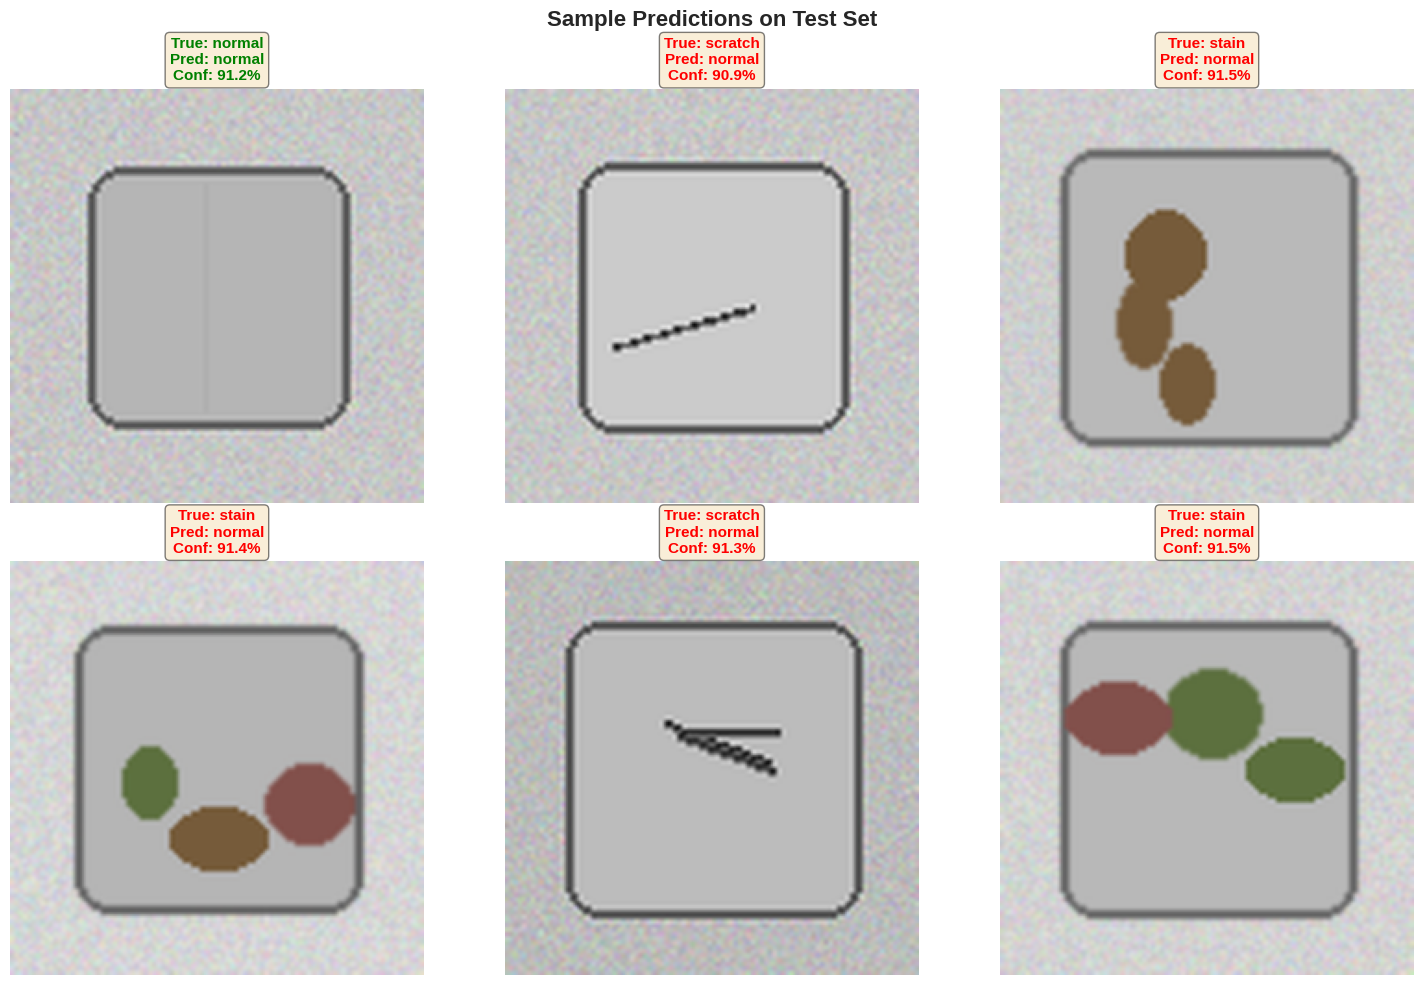

Sample predictions visualization saved!


In [30]:
# Visualize sample predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Predictions on Test Set', fontsize=16, fontweight='bold')

for idx in range(6):
    ax = axes[idx // 3, idx % 3]

    # Show image
    ax.imshow((X_test[idx] * 255).astype(np.uint8))

    # Get prediction info
    true_class = class_names[y_test[idx]]
    pred_class = class_names[y_pred_classes[idx]]
    confidence = np.max(y_pred[idx]) * 100

    # Color based on correct/incorrect
    is_correct = true_class == pred_class
    color = 'green' if is_correct else 'red'

    title = f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%"
    ax.set_title(title, fontweight='bold', fontsize=11, color=color,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample predictions visualization saved!")

## Task 6: CNN Concept Explanation

See detailed explanations in README.md

## Task 7: Business Use Case Mapping

See detailed explanation in README.md

In [31]:
# Summary of results
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nDataset Statistics:")
print(f"  Total images: {len(X)}")
print(f"  Training set: {len(X_train)} images")
print(f"  Validation set: {len(X_val)} images")
print(f"  Test set: {len(X_test)} images")
print(f"  Classes: {len(class_names)}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE} pixels")

print(f"\nModel Architecture:")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Convolutional blocks: 3")
print(f"  Max pooling layers: 3")
print(f"  Dense layers: 2")

print(f"\nTraining Results:")
print(f"  Epochs trained: {len(history.history['loss'])}")
print(f"  Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"\nTest Set Performance:")
print(f"  Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test loss: {test_loss:.4f}")
print("\n" + "="*60)


FINAL MODEL PERFORMANCE SUMMARY

Dataset Statistics:
  Total images: 480
  Training set: 288 images
  Validation set: 96 images
  Test set: 96 images
  Classes: 4
  Image size: 224x224 pixels

Model Architecture:
  Total parameters: 354,340
  Convolutional blocks: 3
  Max pooling layers: 3
  Dense layers: 2

Training Results:
  Epochs trained: 10
  Final training accuracy: 0.9792
  Final validation accuracy: 0.2500

Test Set Performance:
  Test accuracy: 0.2500 (25.00%)
  Test loss: 4.6059

